# Test `rectirization_py`

This notebook builds the local pybind11 extension and checks that the C++ rectirization algorithm is callable from Python.

In [17]:
%pip install -e . --no-build-isolation

Obtaining file:///workspace/BoxFit
  Checking if build backend supports build_editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for boxfit-rectirization (pyproject.toml) ... done
  Created wheel for boxfit-rectirization: filename=boxfit_rectirization-0.1.0-0.editable-cp312-cp312-linux_x86_64.whl size=2919 sha256=93ae1661cdb8a9e26b3af0ed63998919489f4e3662c8ce490dd4b3bab7273758
  Stored in directory: /tmp/pip-ephem-wheel-cache-drw_qyh5/wheels/1c/21/0b/612aeedad2e0d2bde649d8616af9e2ac4dbdb57d15c4103513
Successfully built boxfit-rectirization
  Attempting uninstall: boxfit-rectirization
    Found existing installation: boxfit-rectirization 0.1.0
    Uninstalling boxfit-rectirization-0.1.0:
      Successfully uninstalled boxfit-rectirization-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [18]:
from IPython.display import SVG, display
import rectirization_py


def run_rectirization(polygon, expected=None):
    rectangles = rectirization_py.rectirize(polygon)
    corners = rectirization_py.rectirize_corners(polygon)

    if expected is not None:
        assert rectangles == expected

    return rectangles, corners


def rectirization_svg(polygon, rectangles, title, scale=80):
    padding = 40
    gap = 80
    header = 34
    xs, ys = zip(*polygon)
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    panel_height = (max_y - min_y) * scale + 2 * padding
    panel_width = (max_x - min_x) * scale + 2 * padding
    svg_width = panel_width * 2 + gap
    svg_height = panel_height + header
    left_offset = 0
    right_offset = panel_width + gap

    def sx(x, offset=0):
        return offset + (x - min_x) * scale + padding

    def sy(y):
        return panel_height - ((y - min_y) * scale + padding) + header

    def polygon_points(offset):
        return " ".join(f"{sx(x, offset)},{sy(y)}" for x, y in polygon)

    colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#76b7b2", "#edc948"]
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{svg_width}" height="{svg_height}" viewBox="0 0 {svg_width} {svg_height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<text x="{svg_width / 2}" y="18" text-anchor="middle" font-family="sans-serif" font-size="16" font-weight="600">{title}</text>',
        f'<text x="{panel_width / 2}" y="38" text-anchor="middle" font-family="sans-serif" font-size="13">Original polygon</text>',
        f'<text x="{right_offset + panel_width / 2}" y="38" text-anchor="middle" font-family="sans-serif" font-size="13">Rectirized polygon</text>',
        f'<polygon points="{polygon_points(left_offset)}" fill="#d9d9d9" fill-opacity="0.35" stroke="black" stroke-width="3"/>',
    ]

    for i, (x, y, width, height) in enumerate(rectangles):
        color = colors[i % len(colors)]
        parts.append(
            f'<rect x="{sx(x, right_offset)}" y="{sy(y + height)}" width="{width * scale}" height="{height * scale}" '
            f'fill="{color}" fill-opacity="0.35" stroke="{color}"/>'
        )
        parts.append(
            f'<text x="{sx(x + width / 2, right_offset)}" y="{sy(y + height / 2)}" text-anchor="middle" '
            f'dominant-baseline="middle" font-family="sans-serif" font-size="18">{i + 1}</text>'
        )

    parts.append(f'<polygon points="{polygon_points(right_offset)}" fill="none" stroke="black" stroke-width="3"/>')
    parts.append('</svg>')
    return SVG("".join(parts))


def show_rectirization(polygon, rectangles, title, scale=80):
    display(rectirization_svg(polygon, rectangles, title, scale=scale))

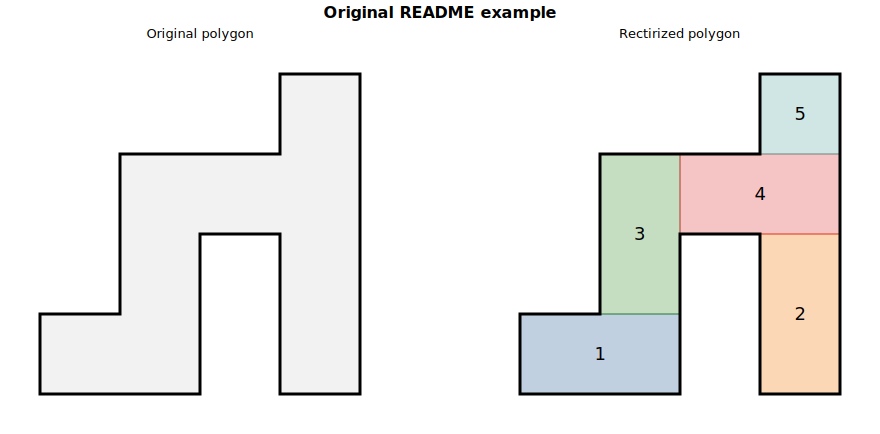

[[1.0, 1.0, 2.0, 1.0],
 [4.0, 1.0, 1.0, 2.0],
 [2.0, 2.0, 1.0, 2.0],
 [3.0, 3.0, 2.0, 1.0],
 [4.0, 4.0, 1.0, 1.0]]

In [19]:
old_polygon = [
    (1, 1),
    (3, 1),
    (3, 3),
    (4, 3),
    (4, 1),
    (5, 1),
    (5, 5),
    (4, 5),
    (4, 4),
    (2, 4),
    (2, 2),
    (1, 2),
]

old_expected = [
    [1.0, 1.0, 2.0, 1.0],
    [4.0, 1.0, 1.0, 2.0],
    [2.0, 2.0, 1.0, 2.0],
    [3.0, 3.0, 2.0, 1.0],
    [4.0, 4.0, 1.0, 1.0],
]

old_rectangles, old_corners = run_rectirization(old_polygon, old_expected)
show_rectirization(old_polygon, old_rectangles, "Original README example")
old_rectangles

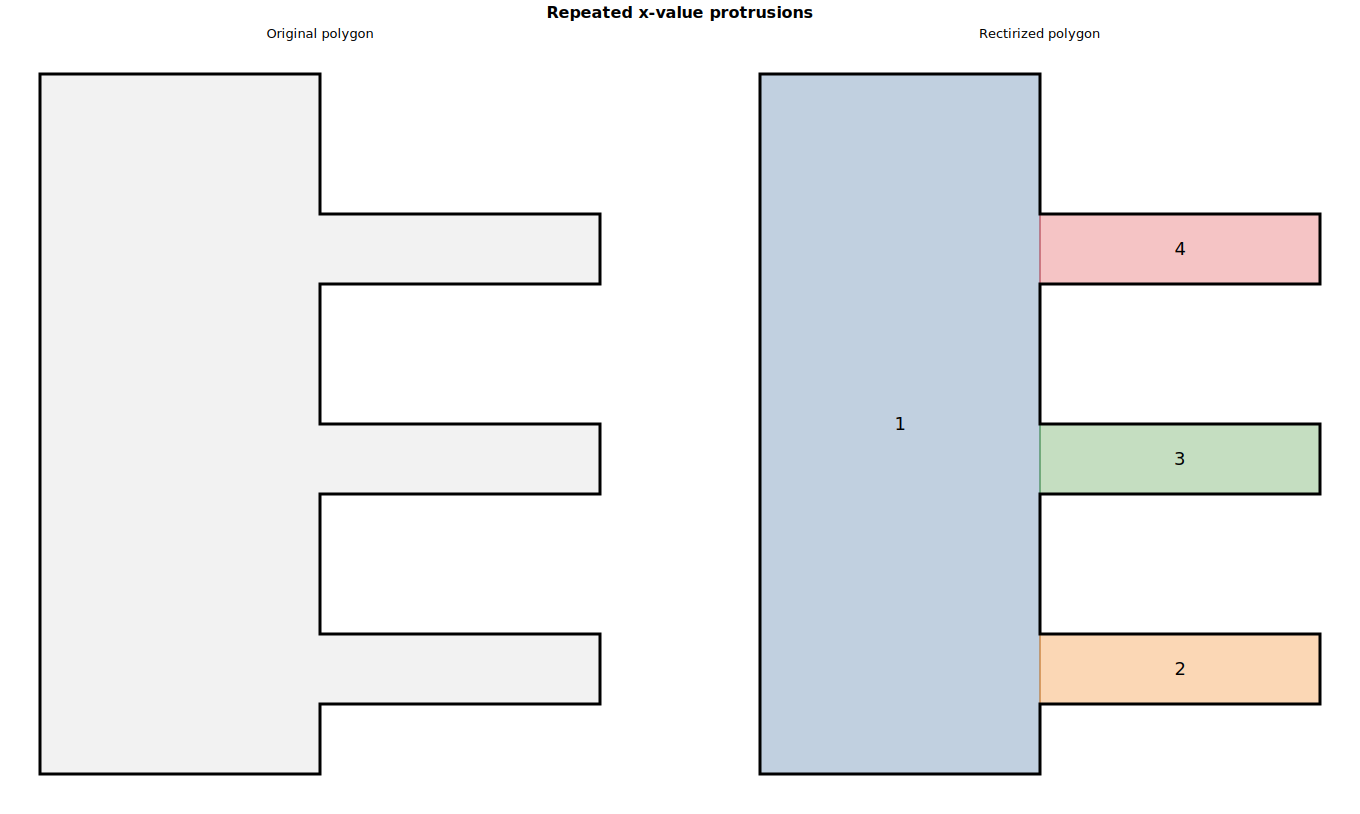

[[0.0, 0.0, 4.0, 10.0],
 [4.0, 1.0, 4.0, 1.0],
 [4.0, 4.0, 4.0, 1.0],
 [4.0, 7.0, 4.0, 1.0]]

In [20]:
shared_x_polygon = [
    (0, 0),
    (4, 0),
    (4, 1),
    (8, 1),
    (8, 2),
    (4, 2),
    (4, 4),
    (8, 4),
    (8, 5),
    (4, 5),
    (4, 7),
    (8, 7),
    (8, 8),
    (4, 8),
    (4, 10),
    (0, 10),
]

shared_x_expected = [
    [0.0, 0.0, 4.0, 10.0],
    [4.0, 1.0, 4.0, 1.0],
    [4.0, 4.0, 4.0, 1.0],
    [4.0, 7.0, 4.0, 1.0],
]

shared_x_rectangles, shared_x_corners = run_rectirization(shared_x_polygon, shared_x_expected)
show_rectirization(shared_x_polygon, shared_x_rectangles, "Repeated x-value protrusions", scale=70)
shared_x_rectangles